In [4]:
#%pip install yfinance

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
import os

In [2]:
# 1. Definir el ticker
ticker_symbol = "BAC"

# 2. Crear el objeto Ticker y descargar el historial
y_ticker = yf.Ticker(ticker_symbol)
historial = y_ticker.history(period="max")

price_avg = (historial['Close'] + historial['Open'] + historial['High'] + historial['Low']) / 4

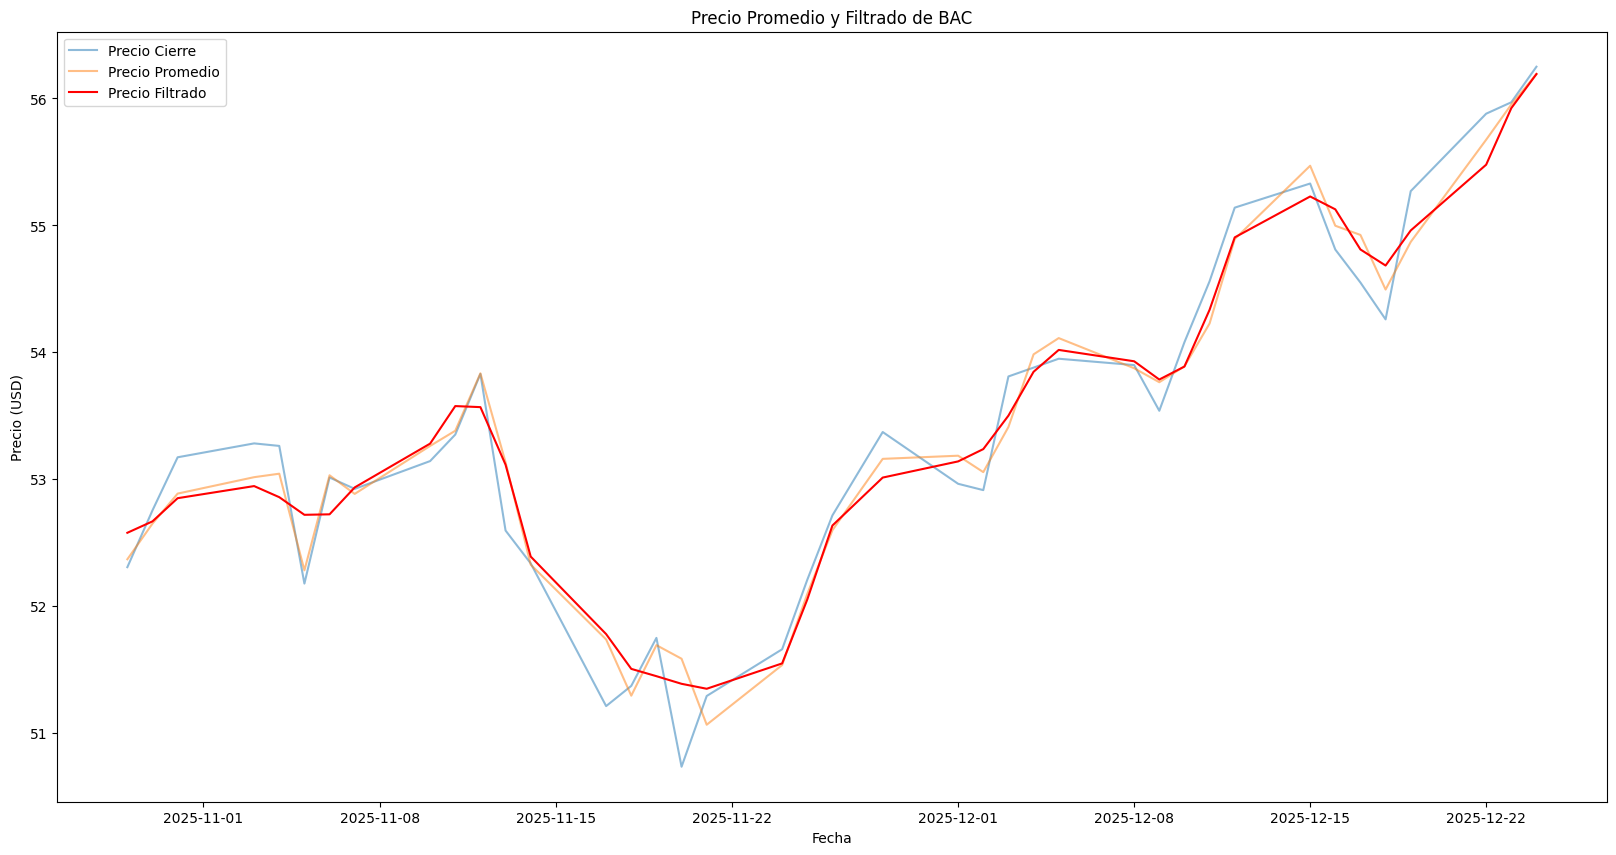

In [3]:
# low pass filter
order = 3
cutoff_freq = 0.2
fs = 1.0  # Sampling frequency (1 sample per day)
b, a = butter(order, cutoff_freq, btype='low', fs=fs)
price_filtered = filtfilt(b, a, price_avg)

n = 40
plt.figure(figsize=(20, 10))
plt.plot(historial.index[-n:], historial['Close'].iloc[-n:], label='Precio Cierre', alpha=0.5)
plt.plot(historial.index[-n:], price_avg[-n:], label='Precio Promedio', alpha=0.5)
plt.plot(historial.index[-n:], price_filtered[-n:], label='Precio Filtrado', color='red')
plt.title('Precio Promedio y Filtrado de BAC')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.show()

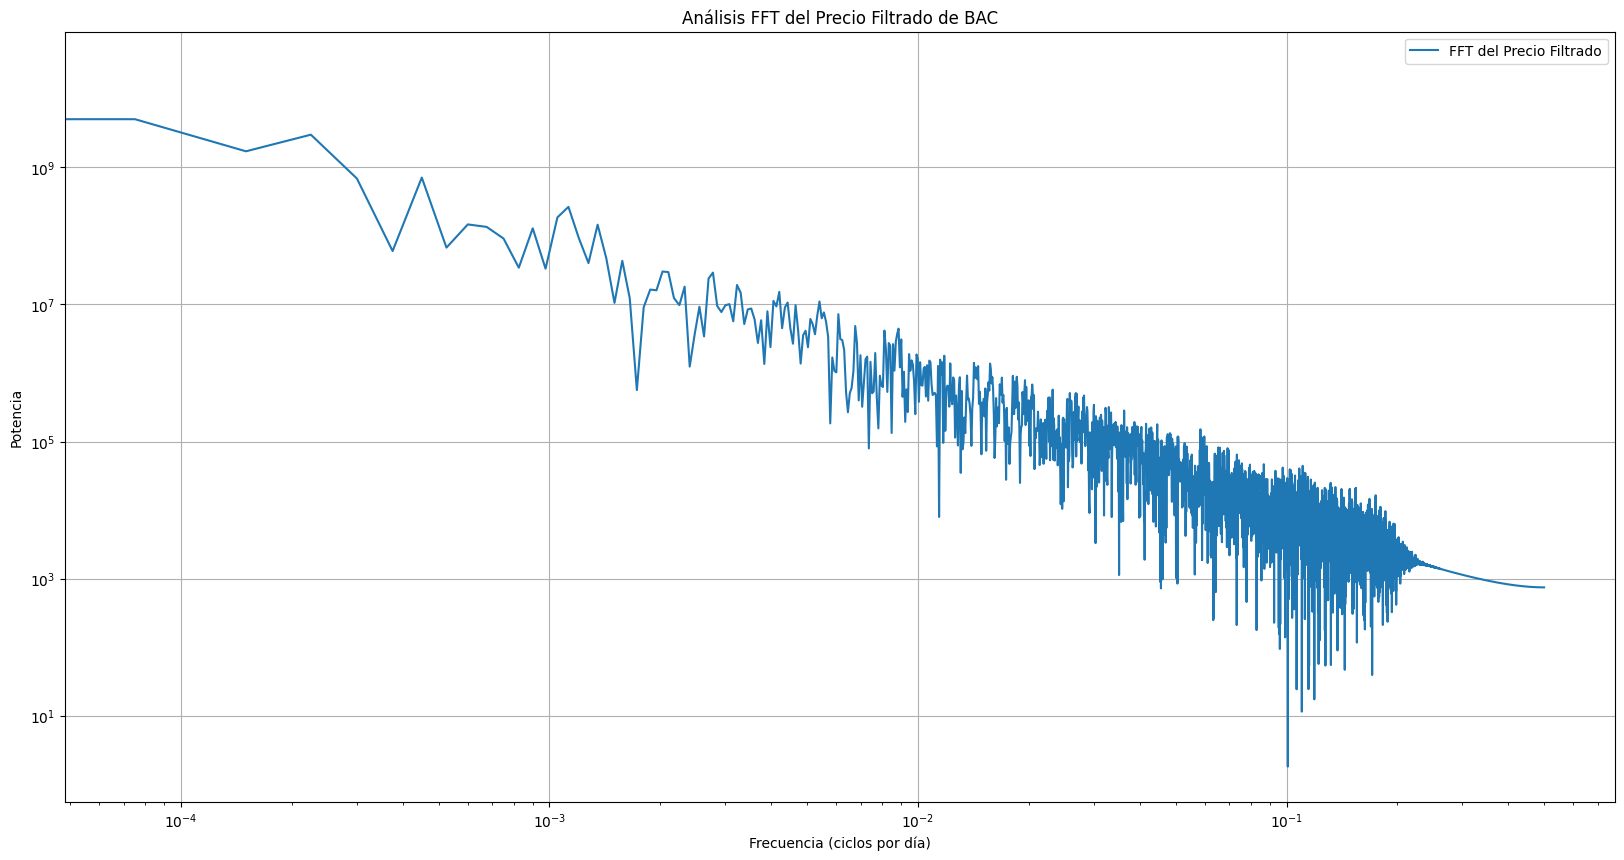

In [32]:
# fft analysis
price_fft = np.fft.fft(price_filtered)
frequencies = np.linspace(0, 0.5, len(price_fft)//2 +1)

plt.figure(figsize=(20, 10))
plt.loglog(frequencies, np.abs(price_fft[:len(frequencies)])**2, label='FFT del Precio Filtrado')
plt.title('Análisis FFT del Precio Filtrado de BAC')
plt.xlabel('Frecuencia (ciclos por día)')
plt.ylabel('Potencia')
plt.legend()
plt.grid(True)
plt.show()